# 🎯 Code-Generation Uncertainty Quantification

<div style="background-color: rgba(200, 200, 200, 0.1); padding: 20px; border-radius: 8px; margin-bottom: 20px; border: 1px solid rgba(127, 127, 127, 0.2); max-width: 97.5%; overflow-wrap: break-word;">
  <p style="font-size: 16px; line-height: 1.6">
    Code-Generation Uncertainty Quantification (UQ) methods estimate response-level confidence scores for coding tasks. This demo provides an illustration 
    of how to use state-of-the-art UQ methods with <code>uqlm</code>. Here is the list of available scores:
  </p>
      
*   Black-Box UQ ["functional_entropy", "semantic_sets", "cosine_sim"]
*   White-Box UQ ["sequence_probability", "min_probability", "mean_token_negentropy", "min_token_negentropy", "probability_margin", "p_true", "monte_carlo_probability"]
*   Judges ["codebleu", "code_equivalence", 
         "verbalized_confidence"]

</div>

## 📊 What You'll Do in This Demo

<div style="display: flex; margin-bottom: 15px; align-items: center">
  <div style="background-color: #34a853; color: white; border-radius: 50%; width: 30px; height: 30px; display: flex; justify-content: center; align-items: center; margin-right: 15px; flex-shrink: 0"><strong>1</strong></div>
  <div>
    <p style="margin: 0; font-weight: bold"><a href=#section1>Set up LLM and prompts.</a></p>
    <p style="margin: 0; color: rgba(95, 99, 104, 0.8)">Set up LLM instance and load example data prompts.</p>
  </div>
</div>

<div style="display: flex; margin-bottom: 15px; align-items: center">
  <div style="background-color: #34a853; color: white; border-radius: 50%; width: 30px; height: 30px; display: flex; justify-content: center; align-items: center; margin-right: 15px; flex-shrink: 0"><strong>2</strong></div>
  <div>
    <p style="margin: 0; font-weight: bold"><a href=#section2>Generate LLM Responses and Confidence Scores</a></p>
    <p style="margin: 0; color: rgba(95, 99, 104, 0.8)">Generate and score LLM responses to the example questions using the <code>CodeGenUQ()</code> class.</p>
  </div>
</div>

<div style="display: flex; margin-bottom: 25px; align-items: center">
  <div style="background-color: #34a853; color: white; border-radius: 50%; width: 30px; height: 30px; display: flex; justify-content: center; align-items: center; margin-right: 15px; flex-shrink: 0"><strong>3</strong></div>
  <div>
    <p style="margin: 0; font-weight: bold"><a href=#section3>Evaluate Hallucination Detection Performance</a></p>
    <p style="margin: 0; color: rgba(95, 99, 104, 0.8)">Visualize model accuracy at different thresholds of the various code-gen UQ confidence scores. Compute precision, recall, and F1-score of hallucination detection.</p>
  </div>
</div>

## ⚖️ Advantages & Limitations

<div style="display: flex; gap: 20px">
  <div style="flex: 1; background-color: rgba(0, 200, 0, 0.1); padding: 15px; border-radius: 8px; border: 1px solid rgba(0, 200, 0, 0.2)">
    <h3 style="color: #2e8b57; margin-top: 0">Pros</h3>
    <ul style="margin-bottom: 0">
      <li><strong>Flexible:</strong> Works with various Black-box and White-box scorers</li>
    </ul>
  </div>
  
  <div style="flex: 1; background-color: rgba(200, 0, 0, 0.1); padding: 15px; border-radius: 8px; border: 1px solid rgba(200, 0, 0, 0.2)">
    <h3 style="color: #b22222; margin-top: 0">Cons</h3>
    <ul style="margin-bottom: 0">
      <li><strong>Higher Cost:</strong> Requires multiple generations per prompt</li>
      <li><strong>Slower:</strong> Multiple and long generations and comparisons increase latency</li>
    </ul>
  </div>
</div>

In [1]:
import numpy as np
import pandas as pd

from uqlm import CodeGenUQ
from uqlm.utils.dataloader import load_example_dataset
from uqlm.utils.prompts.codegen import python_prompt_template, python_prompt_template_stdio
from uqlm.code.code_evaluation import evaluate_python_code

<a id='section1'></a>
## 1. Set up LLM and Prompts

In this demo, we will illustrate this approach using a set of Python coding problems from the [LiveCodeBench benchmark](https://livecodebench.github.io/). To implement with your use case, simply **replace the example prompts with your data**.  

In [2]:
df = load_example_dataset("livecodebench")[["question_content", "platform", "starter_code", "public_test_cases", "metadata", "difficulty"]]
df = df.loc[df.difficulty != "easy"].sample(50).reset_index(drop=True)

Loading dataset - livecodebench...


Using the latest cached version of the dataset since livecodebench/code_generation_lite couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'release_latest' at /Users/c594266/.cache/huggingface/datasets/livecodebench___code_generation_lite/release_latest/0.0.0/4c038560f391c4c05fdf7fd7ae61ae0e6dbd8672f8fe5b95597b78a8dc40a417 (last modified on Thu Feb  5 10:23:28 2026).


Processing dataset...
Dataset ready!


In [3]:
df.head()

,question_content,platform,starter_code,public_test_cases,metadata,difficulty
0,"You are given two integer arrays, nums and cos...",leetcode,"class Solution:\n def minimumCost(self, num...","[{""input"": ""[3, 1, 4]\n[4, 6, 6]\n1"", ""output""...","{""func_name"": ""minimumCost""}",hard
1,You are given an integer array nums and a posi...,leetcode,"class Solution:\n def maxValue(self, nums: ...","[{""input"": ""[2, 6, 7]\n1"", ""output"": ""5"", ""tes...","{""func_name"": ""maxValue""}",hard
2,You are given two strings word1 and word2.\nA ...,leetcode,class Solution:\n def validSubstringCount(s...,"[{""input"": ""\""bcca\""\n\""abc\"""", ""output"": ""1"",...","{""func_name"": ""validSubstringCount""}",medium
3,"You are given an integer array groups, where g...",leetcode,"class Solution:\n def assignElements(self, ...","[{""input"": ""[8, 4, 3, 2, 4]\n[4, 2]"", ""output""...","{""func_name"": ""assignElements""}",medium
4,You are given an array of positive integers nu...,leetcode,"class Solution:\n def countOfPairs(self, nu...","[{""input"": ""[2, 3, 2]"", ""output"": ""4"", ""testty...","{""func_name"": ""countOfPairs""}",hard


In [4]:
prompts = []
for i in range(len(df)):
    # For callable-style questions
    if df["platform"].iloc[i] == "leetcode":
        prompt = python_prompt_template(df["question_content"].iloc[i], df["starter_code"].iloc[i])

    # For I/O style questions
    else:
        prompt = python_prompt_template_stdio(df["question_content"].iloc[i])
    prompts.append(prompt)

In this example, we use `AzureChatOpenAI` to instantiate our LLM, but any [LangChain Chat Model](https://js.langchain.com/docs/integrations/chat/) may be used. Be sure to **replace with your LLM of choice.**

In [5]:
from langchain_google_vertexai import ChatVertexAI

llm = ChatVertexAI(model_name="gemini-2.5-flash")

/var/folders/97/lhjhllnd2_lgbvwlwkv3c9fj4yf262/T/ipykernel_80609/211349119.py:3: DeprecationWarning: Use [`ChatGoogleGenerativeAI`][langchain_google_genai.ChatGoogleGenerativeAI] instead.
  llm = ChatVertexAI(model_name="gemini-2.5-flash")
/var/folders/97/lhjhllnd2_lgbvwlwkv3c9fj4yf262/T/ipykernel_80609/211349119.py:3: LangChainDeprecationWarning: The class `ChatVertexAI` was deprecated in LangChain 3.2.0 and will be removed in 4.0.0. An updated version of the class exists in the `langchain-google-genai package and should be used instead. To use it run `pip install -U `langchain-google-genai` and import as `from `langchain_google_genai import ChatGoogleGenerativeAI``.
  llm = ChatVertexAI(model_name="gemini-2.5-flash")


<a id='section2'></a>
## 2. Generate LLM Responses and Confidence Scores

### `CodeGenUQ()` - Generate LLM responses for Code generation tasks and compute confidence scores for each response.

<!-- ![Sample Image](https://raw.githubusercontent.com/cvs-health/uqlm/develop/assets/images/black_box_graphic.png) -->

#### 📋 Class Attributes

<table style="border-collapse: collapse; width: 100%; border: 1px solid rgba(127, 127, 127, 0.2);">
  <tr>
    <th style="background-color: rgba(200, 200, 200, 0.2); width: 20%; padding: 8px; text-align: left; border: 1px solid rgba(127, 127, 127, 0.2);">Parameter</th>
    <th style="background-color: rgba(200, 200, 200, 0.2); width: 25%; padding: 8px; text-align: left; border: 1px solid rgba(127, 127, 127, 0.2);">Type & Default</th>
    <th style="background-color: rgba(200, 200, 200, 0.2); width: 55%; padding: 8px; text-align: left; border: 1px solid rgba(127, 127, 127, 0.2);">Description</th>
  </tr>
  <tr>
    <td style="font-weight: bold; padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">llm</td>
    <td style="padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">BaseChatModel<br><code>default=None</code></td>
    <td style="padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">A langchain llm `BaseChatModel`. User is responsible for specifying temperature and other relevant parameters to the constructor of the provided `llm` object.</td>
  </tr>
  <tr>
    <td style="font-weight: bold; padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">scorers</td>
    <td style="padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">List[str]<br><code>default=None</code></td>
    <td style="padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">Specifies which scorers to include. Must be subset of ["sequence_probability", "min_probability", "mean_token_negentropy","min_token_negentropy", "probability_margin", "p_true", "consistency_and_confidence", "monte_carlo_probability", "code_bleu","functional_equivalence_rate", "verbalized_confidence", "functional_negentropy", "functional_sets_confidence", "cosine_sim"]. If None, defaults to ["functional_equivalence_rate", "cosine_sim"].
  </tr>    
  <tr>
    <td style="font-weight: bold; padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">system_prompt</td>
    <td style="padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">str or None<br><code>default="You are a helpful assistant."</code></td>
    <td style="padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">Optional argument for user to provide custom system prompt for the LLM.</td>
  </tr>
  <tr>
    <td style="font-weight: bold; padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">max_calls_per_min</td>
    <td style="padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">int<br><code>default=None</code></td>
    <td style="padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">Specifies how many API calls to make per minute to avoid rate limit errors. By default, no limit is specified.</td>
  </tr>
  <tr>
    <td style="font-weight: bold; padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">sampling_temperature</td>
    <td style="padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">float<br><code>default=1</code></td>
    <td style="padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">The 'temperature' parameter for LLM to use when generating sampled LLM responses. Must be greater than 0.</td>
  </tr>
  <tr>
    <td style="font-weight: bold; padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">sentence_transformer</td>
    <td style="padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">str<br><code>default="sentence-transformers/all-MiniLM-L6-v2"</code></td>
    <td style="padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">Specifies which huggingface sentence transformer to use when computing cosine similarity for consistency_and_confidence. See https://huggingface.co/sentence-transformers?sort_models=likes#models for more information. The recommended sentence transformer is 'sentence-transformers/all-MiniLM-L6-v2'.</td>
  </tr>  


</table>

#### 🔍 Parameter Groups

<div style="display: flex; gap: 20px; margin-bottom: 20px">
  <div style="flex: 1; padding: 10px; background-color: rgba(0, 100, 200, 0.1); border-radius: 5px; border: 1px solid rgba(0, 100, 200, 0.2);">
    <p style="font-weight: bold">🧠 LLM-Specific</p>
    <ul>
      <li><code>llm</code></li>
      <li><code>system_prompt</code></li>
      <li><code>sampling_temperature</code></li>
    </ul>
  </div>
  <div style="flex: 1; padding: 10px; background-color: rgba(0, 200, 0, 0.1); border-radius: 5px; border: 1px solid rgba(0, 200, 0, 0.2);">
    <p style="font-weight: bold">📊 Confidence Scores</p>
    <ul>
      <li><code>scorers</code></li>
      <li><code>use_best</code></li>
      <li><code>nli_model_name</code></li>
      <li><code>sentence_transformer</code></li>
      <li><code>postprocessor</code></li>
    </ul>
  </div>
  <div style="flex: 1; padding: 10px; background-color: rgba(200, 150, 0, 0.1); border-radius: 5px; border: 1px solid rgba(200, 150, 0, 0.2);">
    <p style="font-weight: bold">🖥️ Hardware</p>
    <ul>
      <li><code>device</code></li>
    </ul>
  </div>
  <div style="flex: 1; padding: 10px; background-color: rgba(200, 0, 200, 0.1); border-radius: 5px; border: 1px solid rgba(200, 0, 200, 0.2);">
    <p style="font-weight: bold">⚡ Performance</p>
    <ul>
      <li><code>max_calls_per_min</code></li>
      <li><code>use_n_param</code></li>
    </ul>
  </div>
</div>


In [6]:
scorers = ["functional_equivalence_rate", "cosine_sim"]

cg = CodeGenUQ(llm=llm, language="python", scorers=scorers)

/Users/c594266/.cache/huggingface/modules/transformers_modules/jinaai/jina_hyphen_bert_hyphen_v2_hyphen_qk_hyphen_post_hyphen_norm/3baf9e3ac750e76e8edd3019170176884695fb94/configuration_bert.py:29: UserWarning: optimum is not installed. To use OnnxConfig and BertOnnxConfig, make sure that `optimum` package is installed
  warnings.warn("optimum is not installed. To use OnnxConfig and BertOnnxConfig, make sure that `optimum` package is installed")


### 🔄 Class Methods

<table style="border-collapse: collapse; width: 100%; border: 1px solid rgba(127, 127, 127, 0.2);">
  <tr>
    <th style="background-color: rgba(200, 200, 200, 0.2); width: 25%; padding: 8px; text-align: left; border: 1px solid rgba(127, 127, 127, 0.2);">Method</th>
    <th style="background-color: rgba(200, 200, 200, 0.2); width: 75%; padding: 8px; text-align: left; border: 1px solid rgba(127, 127, 127, 0.2);">Description & Parameters</th>
  </tr>
  <tr>
    <td style="font-weight: bold; vertical-align: top; padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">CodeGenUQ.generate_and_score</td>
    <td style="padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">
      <p>Generate LLM responses, sampled LLM (candidate) responses, and compute confidence scores for the provided prompts.</p>
      <p><strong>Parameters:</strong></p>
      <ul>
        <li><code>prompts</code> - (<strong>List[str] or List[List[BaseMessage]]</strong>) A list of input prompts for the model.</li>
        <li><code>num_responses</code> - (<strong>int, default=5</strong>) The number of sampled responses used to compute consistency.</li>
        <li><code>show_progress_bars</code> - (<strong>bool, default=True</strong>) If True, displays a progress bar while generating and scoring responses.</li>        
      </ul>
      <p><strong>Returns:</strong> <code>UQResult</code> containing data (prompts, responses, sampled responses, and confidence scores) and metadata</p>
      <div style="background-color: rgba(0, 200, 0, 0.1); padding: 8px; border-radius: 3px; margin-top: 10px; border: 1px solid rgba(0, 200, 0, 0.2); margin-right: 5px; box-sizing: border-box; width: 100%;">
        <strong>💡 Best For:</strong> Complete end-to-end uncertainty quantification when starting with prompts.
      </div>
    </td>
  </tr>
  <tr>
    <td style="font-weight: bold; vertical-align: top; padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">CodeGenUQ.score</td>
    <td style="padding: 8px; border: 1px solid rgba(127, 127, 127, 0.2);">
      <p>Compute confidence scores on provided LLM responses. Should only be used if responses and sampled responses are already generated.</p>
      <p><strong>Parameters:</strong></p>
      <ul>
        <li><code>responses</code> - (<strong>List[str]</strong>) A list of LLM responses for the prompts.</li>
        <li><code>sampled_responses</code> - (<strong>List[List[str]]</strong>) A list of lists of sampled LLM responses for each prompt. Used to compute consistency scores by comparing to the corresponding response from <code>responses</code>.</li>
        <li><code>show_progress_bars</code> - (<strong>bool, default=True</strong>) If True, displays a progress bar while scoring responses.</li>  
      </ul>
      <p><strong>Returns:</strong> <code>UQResult</code> containing data (responses, sampled responses, and confidence scores) and metadata</p>
      <div style="background-color: rgba(0, 200, 0, 0.1); padding: 8px; border-radius: 3px; margin-top: 10px; border: 1px solid rgba(0, 200, 0, 0.2); margin-right: 5px; box-sizing: border-box; width: 100%;">
        <strong>💡 Best For:</strong> Computing uncertainty scores when responses are already generated elsewhere.
      </div>
    </td>
  </tr>
</table>

In [7]:
results = await cg.generate_and_score(prompts=prompts, num_responses=5)
result_df = results.to_df()
result_df.head()

Output()

Retrying langchain_google_vertexai.chat_models._acompletion_with_retry.<locals>._completion_with_retry_inner in 4.0
seconds as it raised ResourceExhausted: 429 Resource exhausted. Please try again later. Please refer to 
https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details..

Retrying langchain_google_vertexai.chat_models._acompletion_with_retry.<locals>._completion_with_retry_inner in 4.0
seconds as it raised ResourceExhausted: 429 Resource exhausted. Please try again later. Please refer to 
https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details..

,prompt,response,sampled_responses,logprob,sampled_logprob,cosine_sim,functional_equivalence_rate
0,\nYou are an expert Python programmer. You alw...,import collections\n\nclass Solution:\n def...,[```python\nimport collections\nfrom typing im...,"[[{'token': '```', 'logprob': -0.0152851352468...","[[{'token': '```', 'logprob': -0.0152851352468...",0.965088,0.8
1,\nYou are an expert Python programmer. You alw...,```python\nimport collections\nfrom typing imp...,[```python\nfrom typing import List\n\nclass S...,"[[{'token': '```', 'logprob': -0.0122611336410...","[[{'token': '```', 'logprob': -0.0122611336410...",0.917892,0.6
2,\nYou are an expert Python programmer. You alw...,```python\nimport collections\n\nclass Solutio...,[import collections\n\nclass Solution:\n de...,"[[{'token': 'import', 'logprob': -1.5904875993...","[[{'token': 'import', 'logprob': -1.5904875993...",0.978254,0.2
3,\nYou are an expert Python programmer. You alw...,import math\n\nclass Solution:\n def assign...,[```python\nimport math\nfrom typing import Li...,"[[{'token': '```', 'logprob': -0.1582542955875...","[[{'token': '```', 'logprob': -0.1582542955875...",0.973631,0.8
4,\nYou are an expert Python programmer. You alw...,"class Solution:\n def countOfPairs(self, nu...",[```python\nimport collections\n\nclass Soluti...,"[[{'token': '```', 'logprob': -0.0965872779488...","[[{'token': '```', 'logprob': -0.0965872779488...",0.964737,1.0


<a id='section3'></a>
## 3. Evaluate Hallucination Detection Performance

To evaluate hallucination detection performance, we 'grade' the responses against an answer key. Here, we use a wrapper on LiveCodeBench's grader method. **If you are using your own prompts/questions, be sure to update the test cases and grading method accordingly**.

In [ ]:
# Combine CodeGenUQ outputs with all benchmark data
result_df = pd.concat([result_df, df.loc[:, ~df.columns.isin(result_df.columns)]], axis=1)

responses = result_df["response"].to_list()
public_test_cases = result_df["public_test_cases"].to_list()
metadata = result_df["metadata"].to_list()

# Use uqlm python grader utility `evaluate_python_code` to evaluate whether unit tests pass
result_dict = evaluate_python_code(responses=responses, public_test_cases=public_test_cases, metadata=metadata)

#  Convert results to DataFrame
eval_df = pd.DataFrame(result_dict)

for col in eval_df.columns:
    result_df[col] = eval_df[col].values

result_df.head()

I0000 00:00:1776365207.792242 1151674 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776365208.586163 1151674 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776365208.821025 1151674 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776365209.084193 1151674 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776365209.362602 1151674 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776365209.625840 1151674 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776365209.891995 1151674 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1776365210.187462 1151674 fork_posix.cc:71] Other threads are currently calling into gRPC, s

,prompt,response,sampled_responses,logprob,sampled_logprob,cosine_sim,functional_equivalence_rate,question_content,platform,starter_code,public_test_cases,metadata,difficulty,unit_test_passed,stderr
0,\nYou are an expert Python programmer. You alw...,import collections\n\nclass Solution:\n def...,[```python\nimport collections\nfrom typing im...,"[[{'token': '```', 'logprob': -0.0152851352468...","[[{'token': '```', 'logprob': -0.0152851352468...",0.965088,0.8,"You are given two integer arrays, nums and cos...",leetcode,"class Solution:\n def minimumCost(self, num...","[{""input"": ""[3, 1, 4]\n[4, 6, 6]\n1"", ""output""...","{""func_name"": ""minimumCost""}",hard,1,
1,\nYou are an expert Python programmer. You alw...,```python\nimport collections\nfrom typing imp...,[```python\nfrom typing import List\n\nclass S...,"[[{'token': '```', 'logprob': -0.0122611336410...","[[{'token': '```', 'logprob': -0.0122611336410...",0.917892,0.6,You are given an integer array nums and a posi...,leetcode,"class Solution:\n def maxValue(self, nums: ...","[{""input"": ""[2, 6, 7]\n1"", ""output"": ""5"", ""tes...","{""func_name"": ""maxValue""}",hard,0,Wrong Answer
2,\nYou are an expert Python programmer. You alw...,```python\nimport collections\n\nclass Solutio...,[import collections\n\nclass Solution:\n de...,"[[{'token': 'import', 'logprob': -1.5904875993...","[[{'token': 'import', 'logprob': -1.5904875993...",0.978254,0.2,You are given two strings word1 and word2.\nA ...,leetcode,class Solution:\n def validSubstringCount(s...,"[{""input"": ""\""bcca\""\n\""abc\"""", ""output"": ""1"",...","{""func_name"": ""validSubstringCount""}",medium,1,
3,\nYou are an expert Python programmer. You alw...,import math\n\nclass Solution:\n def assign...,[```python\nimport math\nfrom typing import Li...,"[[{'token': '```', 'logprob': -0.1582542955875...","[[{'token': '```', 'logprob': -0.1582542955875...",0.973631,0.8,"You are given an integer array groups, where g...",leetcode,"class Solution:\n def assignElements(self, ...","[{""input"": ""[8, 4, 3, 2, 4]\n[4, 2]"", ""output""...","{""func_name"": ""assignElements""}",medium,1,
4,\nYou are an expert Python programmer. You alw...,"class Solution:\n def countOfPairs(self, nu...",[```python\nimport collections\n\nclass Soluti...,"[[{'token': '```', 'logprob': -0.0965872779488...","[[{'token': '```', 'logprob': -0.0965872779488...",0.964737,1.0,You are given an array of positive integers nu...,leetcode,"class Solution:\n def countOfPairs(self, nu...","[{""input"": ""[2, 3, 2]"", ""output"": ""4"", ""testty...","{""func_name"": ""countOfPairs""}",hard,1,


In [10]:
print(f"""Baseline LLM accuracy (pass@1 score): {np.mean(result_df["unit_test_passed"])}""")

Baseline LLM accuracy (pass@1 score): 0.78


#### 3.1 Filtered LLM Accuracy Evaluation

Here, we explore ‘filtered accuracy’ as a metric for evaluating the performance of our confidence scores. Filtered accuracy measures the change in LLM performance when responses with confidence scores below a specified threshold are excluded. By adjusting the confidence score threshold, we can observe how the accuracy of the LLM improves as less certain responses are filtered out.

We will plot the filtered accuracy across various confidence score thresholds to visualize the relationship between confidence and LLM accuracy. This analysis helps in understanding the trade-off between response coverage (measured by sample size below) and LLM accuracy, providing insights into the reliability of the LLM’s outputs. We conduct this analysis separately for each of our scorers. 

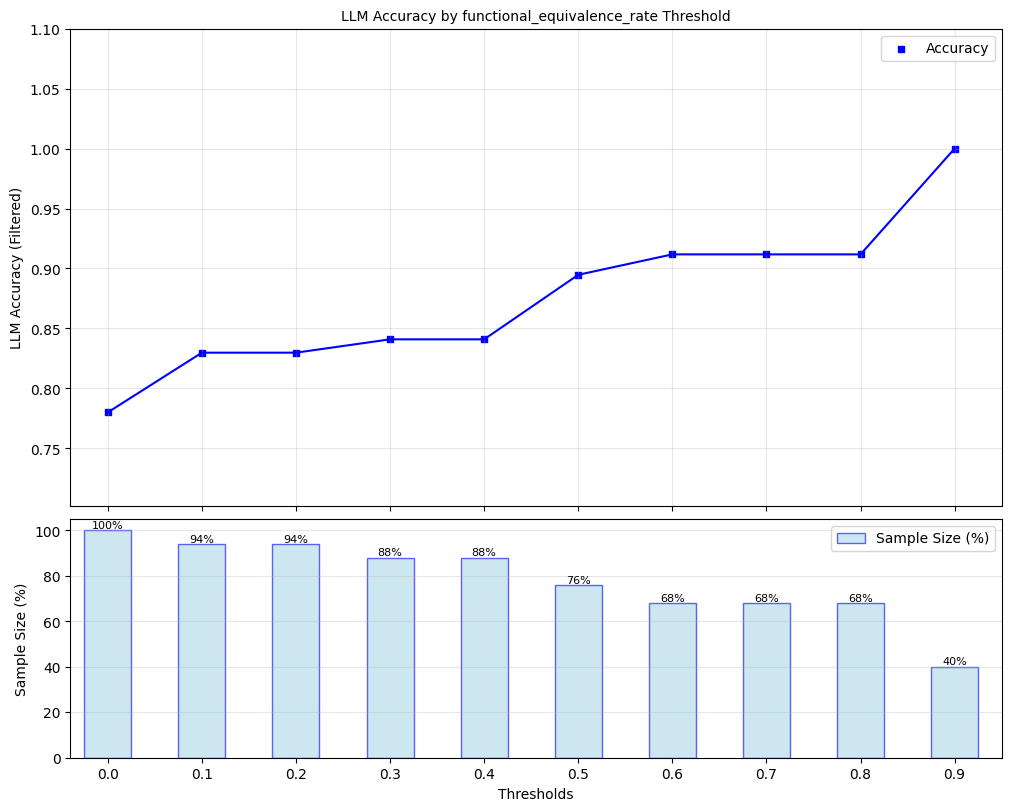

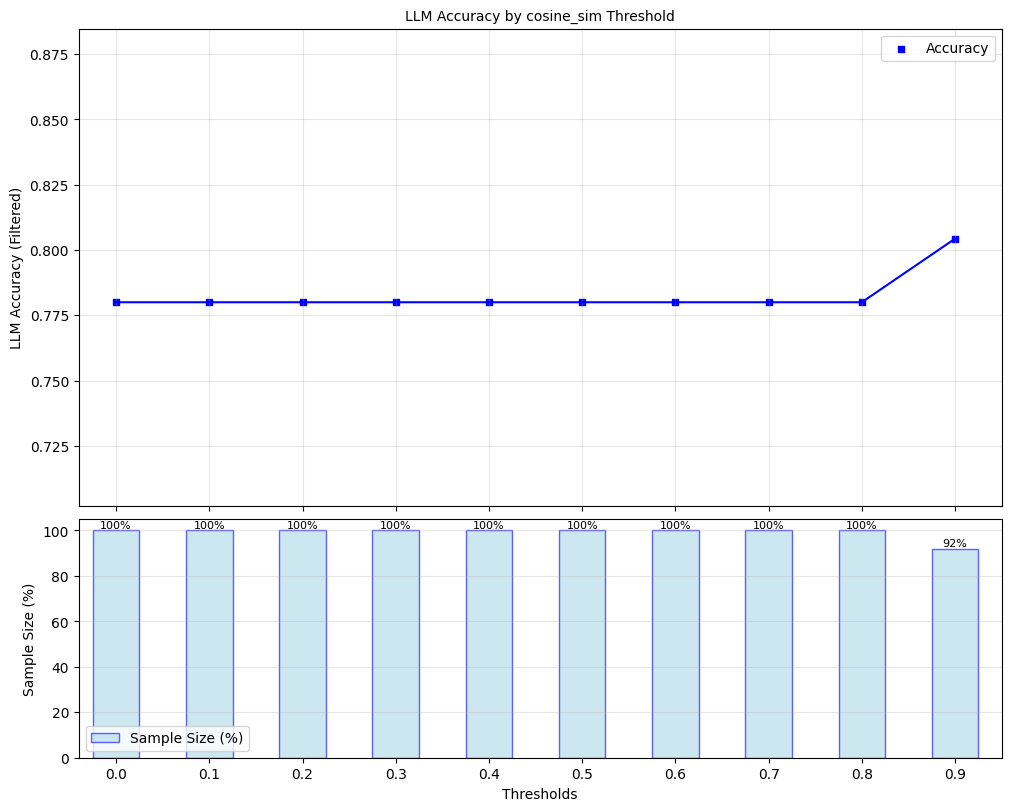

In [11]:
from uqlm.utils import plot_model_accuracies

for confidence_score in scorers:
    plot_model_accuracies(scores=result_df[confidence_score], correct_indicators=result_df.unit_test_passed, title=f"LLM Accuracy by {confidence_score} Threshold", display_percentage=True)

#### 3.2 Precision, Recall, F1-Score of Hallucination Detection

Lastly, we compute the optimal threshold for binarizing confidence scores, using F1-score as the objective. Using this threshold, we compute precision, recall, and F1-score for black box scorer predictions of whether responses are correct.

In [12]:
from uqlm.utils import Tuner
from sklearn.metrics import precision_score, recall_score, f1_score

# instantiate UQLM tuner object for threshold selection
split = len(result_df) // 2
t = Tuner()

correct_indicators = (result_df.unit_test_passed) * 1  # Whether responses is actually correct
metric_values = {"Precision": [], "Recall": [], "F1-score": []}
optimal_thresholds = []
for confidence_score in cg.scorers:
    # tune threshold on first half
    y_scores = result_df[confidence_score]
    y_scores_tune = y_scores[0:split]
    y_true_tune = correct_indicators[0:split]
    best_threshold = t.tune_threshold(y_scores=y_scores_tune, correct_indicators=y_true_tune, thresh_objective="fbeta_score")

    y_pred = [(s > best_threshold) * 1 for s in y_scores]  # predicts whether response is correct based on confidence score
    optimal_thresholds.append(best_threshold)

    # evaluate on last half
    y_true_eval = correct_indicators[split:]
    y_pred_eval = y_pred[split:]
    metric_values["Precision"].append(precision_score(y_true=y_true_eval, y_pred=y_pred_eval))
    metric_values["Recall"].append(recall_score(y_true=y_true_eval, y_pred=y_pred_eval))
    metric_values["F1-score"].append(f1_score(y_true=y_true_eval, y_pred=y_pred_eval))

# print results
header = f"{'Metrics':<35}" + "".join([f"{scorer_name:<35}" for scorer_name in cg.scorers])
print("=" * len(header) + "\n" + header + "\n" + "-" * len(header))
for metric in metric_values.keys():
    print(f"{metric:<35}" + "".join([f"{round(x_, 3):<35}" for x_ in metric_values[metric]]))
print("-" * len(header))
print(f"{'F-1 optimal threshold':<35}" + "".join([f"{round(x_, 3):<35}" for x_ in optimal_thresholds]))
print("=" * len(header))

Metrics                            functional_equivalence_rate        cosine_sim                         
---------------------------------------------------------------------------------------------------------
Precision                          0.818                              0.72                               
Recall                             1.0                                1.0                                
F1-score                           0.9                                0.837                              
---------------------------------------------------------------------------------------------------------
F-1 optimal threshold              0.0                                0.0                                
